In [13]:
df = pd.read_excel('superstore.xls')
sales_by_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
print(sales_by_state.head(10))


State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


In [14]:
comparison = df[df['State'].isin(['California', 'New York'])] \
    .groupby('State')[['Sales', 'Profit']].sum()

print(comparison)

                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


In [15]:
ny_customers = df[df['State'] == 'New York']

top_customer = ny_customers.groupby('Customer Name')['Sales'] \
    .sum() \
    .sort_values(ascending=False)

print(top_customer.head(10))

Customer Name
Tom Ashbrook        13723.498
Peter Fuller         7678.228
Seth Vernon          7359.918
Tom Boeckenhauer     6999.960
Greg Tran            6712.744
Todd Sumrall         6492.314
Karen Daniels        6241.282
Keith Dawkins        5854.194
Luke Weiss           5048.186
Caroline Jumper      5012.760
Name: Sales, dtype: float64


In [18]:
state_metrics = df.groupby('State')[['Sales', 'Profit']].sum()
state_metrics['Profit Margin %'] = (state_metrics['Profit'] / state_metrics['Sales']) * 100

print(state_metrics.sort_values('Profit Margin %', ascending=False))

                            Sales      Profit  Profit Margin %
State                                                         
District of Columbia    2865.0200   1059.5893        36.983662
Delaware               27451.0690   9977.3748        36.346034
Minnesota              29863.1500  10823.1874        36.242618
Maine                   1270.5300    454.4862        35.771387
Arkansas               11678.1300   4008.6871        34.326447
Indiana                53555.3600  18382.9363        34.325110
Georgia                49095.8400  16250.0433        33.098615
Montana                 5589.3520   1833.3285        32.800377
Rhode Island           22627.9560   7285.6293        32.197470
Michigan               76269.6140  24463.1876        32.074618
Kentucky               36591.7500  11199.6966        30.607163
South Dakota            1315.5600    394.8283        30.012185
Maryland               23705.5230   7031.1788        29.660509
Alabama                19510.6400   5786.8253        29

In [19]:
customer_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)

top_20_percent = int(len(customer_profit) * 0.2)

top_profit = customer_profit.head(top_20_percent).sum()

total_profit = customer_profit.sum()

profit_percentage = (top_profit / total_profit) * 100

print(f"Top 20% of customers contribute {profit_percentage:.2f}% of total profit")

Top 20% of customers contribute 81.43% of total profit


Pareto Principle seems to apply here. About 20% of the customers generate roughly 81% of the total profit, which is very close to the 80/20 rule. This means a small group of customers has a major impact on the company’s profitability and could be especially important to focus on.

In [20]:
top_sales_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)

print(top_sales_cities)

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64


In [21]:
top_profit_cities = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)

print(top_profit_cities)

City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64


In [23]:
city_summary = df.groupby('City')[['Sales', 'Profit']].sum()

city_summary['Profit Margin %'] = (city_summary['Profit'] / city_summary['Sales']) * 100

city_summary.sort_values(by='Profit', ascending=False).head(20)

,Sales,Profit,Profit Margin %
City,,,
New York City,256368.161,62036.9837,24.198396
Los Angeles,175851.341,30440.7579,17.310507
Seattle,119540.742,29156.0967,24.390092
San Francisco,112669.092,17507.3854,15.538765
Detroit,42446.944,13181.7908,31.054746
Lafayette,25036.200,10018.3876,40.015608
Jackson,24963.858,7581.6828,30.370637
Atlanta,17197.840,6993.6629,40.665938
Minneapolis,16870.540,6824.5846,40.452674


Yes, there are clear differences in profitability among cities. Some cities generate high sales and strong profits, while others have high sales but much lower profit margins. This shows that strong revenue does not always translate into strong profitability, likely due to differences in discounts, product mix, or operating costs.

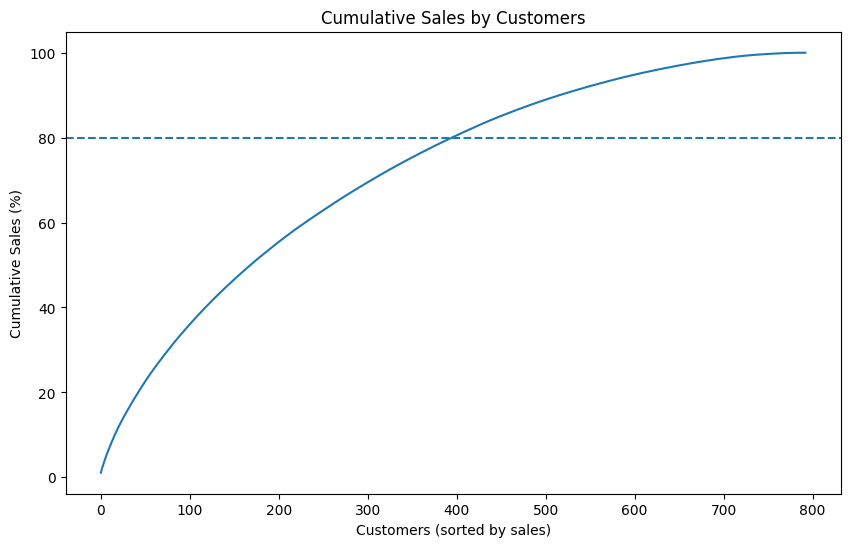

In [24]:
import matplotlib.pyplot as plt


customer_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)


cumulative_sales = customer_sales.cumsum() / customer_sales.sum() * 100


plt.figure(figsize=(10,6))
plt.plot(cumulative_sales.values)
plt.axhline(80, linestyle='--')
plt.xlabel('Customers (sorted by sales)')
plt.ylabel('Cumulative Sales (%)')
plt.title('Cumulative Sales by Customers')
plt.show()

In [25]:
top_20_customers = int(len(customer_sales) * 0.2)

sales_top_20 = customer_sales.head(top_20_customers).sum()

total_sales = customer_sales.sum()

sales_percentage = (sales_top_20 / total_sales) * 100

print(f"Top 20% of customers contribute {sales_percentage:.2f}% of total sales")

Top 20% of customers contribute 47.96% of total sales


No, the Pareto Principle does not strongly apply to customer sales in this dataset. The top 20% of customers contribute approximately 48% of total sales, which is significantly lower than the 80% expected under the Pareto Principle. This suggests that sales are more evenly distributed across customers rather than being concentrated among a small group.